In [95]:
import numpy as np  
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
from astroML.linear_model import PolynomialRegression
from sklearn.metrics import make_scorer, mean_squared_error

Plot the data 

(35.0, 50.0)

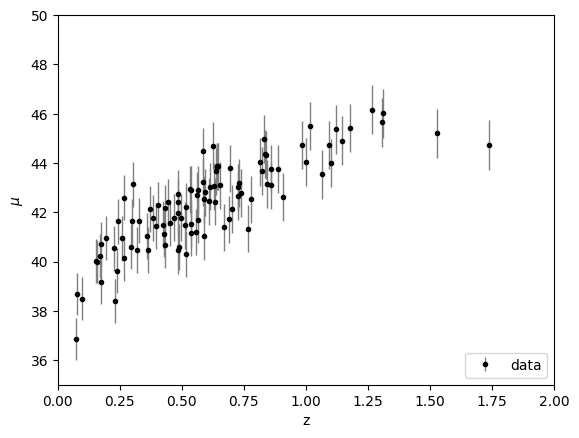

In [96]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Linear regression

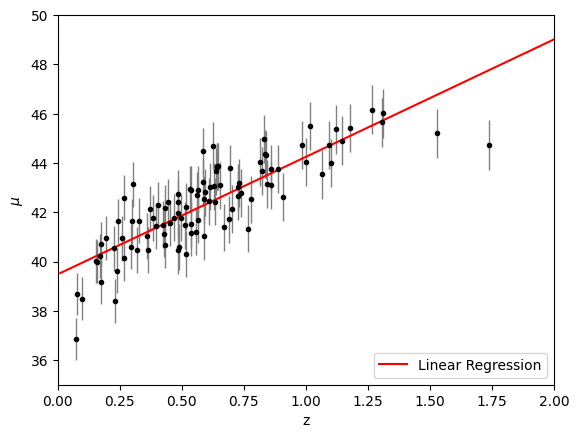

In [97]:
import astroML.linear_model 

z = np.linspace(0.01, 2, 1000) 

regressor = astroML.linear_model.LinearRegression() #regression algorithm 

regressor.fit(z_sample[:,np.newaxis], mu_sample, dmu) #fit the data and then predict on z axis 
mu_fit = regressor.predict(z[:,np.newaxis])

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.plot(z, mu_fit, '-r',label='Linear Regression')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

### Polynomial regression

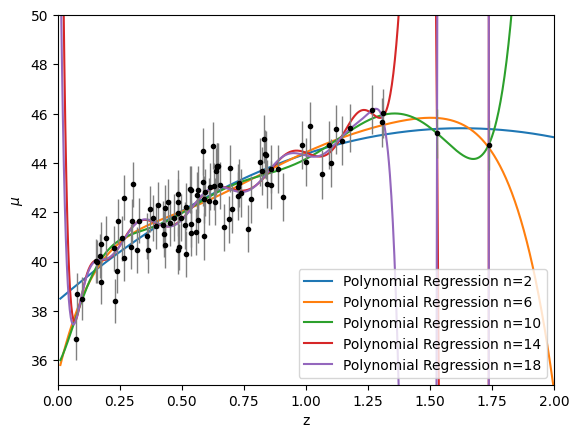

In [98]:
for n in np.arange(1,20)[1::4]:

    regressor = astroML.linear_model.PolynomialRegression(n)
    regressor.fit(z_sample[:,np.newaxis], mu_sample, dmu)
    mu_fit = regressor.predict(z[:,np.newaxis])
    plt.plot(z, mu_fit,label='Polynomial Regression n='+str(n))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

#### K-FOLD CROSS VALIDATION to discover the best model

In [99]:
X_full = z_sample[:, np.newaxis]
y_full = mu_sample
dy_full = dmu

X_trainval, X_test, y_trainval, y_test, dy_trainval, dy_test = train_test_split(
    X_full, y_full, dy_full, test_size=0.1, random_state=8)

Best 2 0.9266993221202373


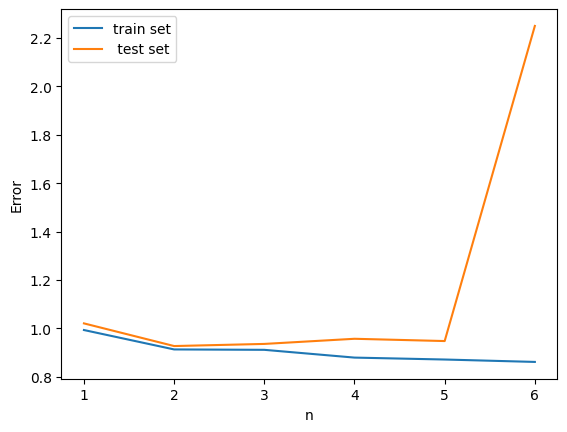

In [100]:
X = z_sample[:, np.newaxis] #right shape for sklearn
y = mu_sample
dy = dmu


kf = KFold(n_splits=5, shuffle=True, random_state=4)

degrees = np.arange(1,7)
train_errors = []
test_errors = []


def my_mae(y_true, y_pred):
    return np.sqrt( np.sum(( y_true - y_pred )**2) / len(y_true) )

mae_scorer = make_scorer(my_mae)


for degree in degrees:
    model = PolynomialRegression(degree)
    
    scores = cross_validate(
        model, X_trainval, y_trainval,
        scoring=mae_scorer,
        cv=kf,
        return_train_score=True
    )

    test_score= np.mean(scores['test_score']) 
    train_score = np.mean(scores['train_score'])

    train_errors.append(train_score)
    test_errors.append(test_score)

plt.plot(degrees,train_errors, label='train set')
plt.plot(degrees,test_errors, label=' test set')

plt.xlabel('n')
plt.ylabel('Error')
plt.legend()

print("Best", degrees[np.argmin(test_errors)], min(test_errors))
Best=degrees[np.argmin(test_errors)]

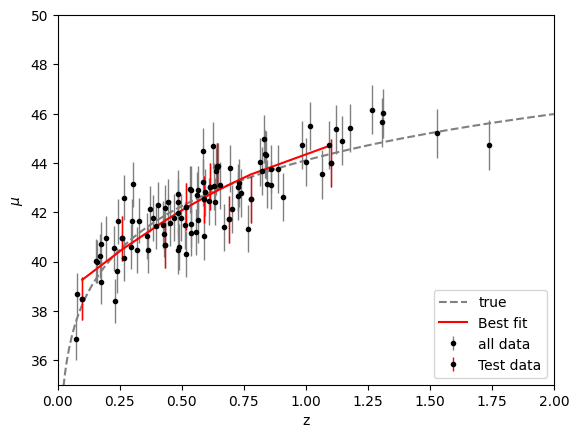

In [115]:
final_model = PolynomialRegression(Best)
final_model.fit(X_trainval, y_trainval, dy_trainval)

y_pred_test = final_model.predict(X_test)

sort_idx = np.argsort(X_test[:, 0])
X_test_sorted = X_test[sort_idx]
y_test_sorted = y_test[sort_idx]
y_pred_sorted = y_pred_test[sort_idx]


from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z = np.linspace(0.01, 2, 1000)
mu_true = cosmo.distmod(z)

plt.plot(z, mu_true, '--', c='gray',label='true') 
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='all data')
plt.xlabel("z")
plt.ylabel("$\mu$")

plt.xlim(0,2)
plt.ylim(35,50);

plt.errorbar(X_test_sorted[:, 0], y_test_sorted, dy_test[sort_idx], fmt='.k', ecolor='red', lw=1, label='Test data')


final_model.fit(X_full, y_full) # in this case dy is irrelevant because errors are homoscedastic
mu_fit = final_model.predict(z[:,np.newaxis])

#plt.plot(z, mu_fit, label='Fit using all data')
plt.plot(X_test_sorted[:, 0], y_pred_sorted, color='red', label='Best fit')
plt.legend(loc='lower right')

Depending on wheter the last points are in the training or test set, the plot will look different.